In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
np.random.seed(2)

In [24]:
df = pd.read_csv('fraudTest.csv')

In [21]:
type(data)

int

Data Exploration

In [60]:
df

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,first,last,gender,street,city,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,normalizedamt
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,Jeff,Elliott,M,351 Darlene Green,Columbia,...,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,-0.424463
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,Joanne,Williams,F,3638 Marsh Union,Altonah,...,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,-0.252337
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,Ashley,Lopez,F,9333 Valentine Point,Bellmore,...,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,-0.179353
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,...,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,-0.059605
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,...,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,-0.422358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,Michael,Olson,M,558 Michael Estates,Luray,...,-91.8912,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0,-0.163467
555715,555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,Jose,Vasquez,M,572 Davis Mountains,Lake Jackson,...,-95.4401,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0,0.270803
555716,555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,Ann,Lawson,F,144 Evans Islands Apt. 683,Burbank,...,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0,0.111564
555717,555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,Eric,Preston,M,7020 Doyle Stream Apt. 951,Mesa,...,-116.4493,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0,-0.391735


In [62]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,first,last,gender,street,city,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,normalizedamt
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,Jeff,Elliott,M,351 Darlene Green,Columbia,...,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,-0.424463
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,Joanne,Williams,F,3638 Marsh Union,Altonah,...,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,-0.252337
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,Ashley,Lopez,F,9333 Valentine Point,Bellmore,...,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,-0.179353
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,...,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,-0.059605
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,...,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,-0.422358


Pre-processing

In [82]:
print(df.columns)

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'first',
       'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long',
       'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'normalizedamt'],
      dtype='object')


In [84]:
from sklearn.preprocessing import StandardScaler

if 'amt' in df.columns:
    scaler = StandardScaler()
    df['normalizedamt'] = scaler.fit_transform(df[['amt']])
    df = df.drop(columns=['amt'])




In [85]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,first,last,gender,street,city,state,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,normalizedamt
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,...,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,-0.424463
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,...,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,-0.252337
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,...,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,-0.179353
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,...,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,-0.059605
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,...,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,-0.422358


In [88]:
df = df.drop(['unix_time'],axis=1)
df.head()

,trans_date_trans_time,cc_num,merchant,category,first,last,gender,street,city,state,...,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud,normalizedamt
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,33.986391,-81.200714,0,-0.424463
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,39.450498,-109.960431,0,-0.252337
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,40.495810,-74.196111,0,-0.179353
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,28.812398,-80.883061,0,-0.059605
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,44.959148,-85.884734,0,-0.422358


In [89]:
X = df.iloc[:, df.columns != 'is_fraud']
Y = df.iloc[:, df.columns == 'is_fraud']

In [90]:
Y.head()

,is_fraud
0,0
1,0
2,0
3,0
4,0


In [91]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.3, random_state=0)

In [92]:
X_train.shape

(389003, 20)

In [93]:
X_test.shape

(166716, 20)

Random Forest

In [94]:
from sklearn.ensemble import RandomForestClassifier

In [95]:
random_forest = RandomForestClassifier(n_estimators=100)

In [99]:
X = df.drop(columns=['is_fraud'])
Y = df['is_fraud']

In [104]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.3,random_state=42,stratify=Y)


In [107]:
df = df.drop(columns=['trans_date_trans_time'])



In [108]:
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']


In [113]:
df.select_dtypes(include='object').columns


Index(['merchant', 'category', 'first', 'last', 'gender', 'street', 'city',
       'state', 'job', 'dob', 'trans_num'],
      dtype='object')

In [132]:
df = df.drop(columns=['dob', 'trans_num'])


In [133]:
categorical_cols = ['category', 'gender', 'state', 'job']

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)


In [134]:
X = df_encoded.drop(columns=['is_fraud'])
y = df_encoded['is_fraud']


In [135]:
X.dtypes[X.dtypes == 'object']


Series([], dtype: object)

In [137]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [140]:
y_pred = rf.predict(X_test)

In [141]:
rf.score(X_test,y_test)

0.9979785983348929

In [149]:
import pickle
with open('rf_model.pkl','wb')as file:
    pickle.dump(rf,file)
print("Random Forest model saved successfully")    

Random Forest model saved successfully


In [150]:
rf_accuracy = rf.score(X_test,y_test)
with open('rf_accuracy.pkl','wb')as file:
    pickle.dump(rf_accuracy,file)

In [152]:
cnf_matrix = confusion_matrix(y_test,y_pred)

In [153]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[166042     30]
 [   307    337]]


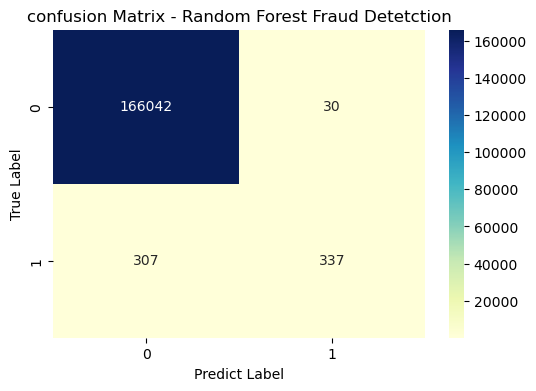

In [156]:
import seaborn as sns
import matplotlib.pyplot as plt
labels = [0,1]
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='YlGnBu',xticklabels=labels,yticklabels=labels)
plt.xlabel("Predict Label")
plt.ylabel("True Label")
plt.title("confusion Matrix - Random Forest Fraud Detetction")
plt.show()